### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 6

1 Implement Simple Naïve Bayes classification algorithm using Python on iris.csv dataset.
2 Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [ ]:
# Naïve Bayes is a probability-based classification algorithm
# Based on Bayes’ Theorem
# Assumes all features are independent (naïve assumption)
# Calculates probability of each class for given input
# Predicts class with highest probability
# Fast, simple, and works well for classification tasks

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, multilabel_confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [54]:
# Load the dataset
iris = pd.read_csv('3ass_iris.csv')   

print("First 5 rows:")
iris.head()

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,5.0,3.4,1.5,0.2,Iris-setosa
3,6.4,3.2,4.5,1.5,Iris-versicolor
4,6.9,3.1,4.9,1.5,Iris-versicolor


In [55]:
# Dataset info
print("\nDataset Info:")    
iris.tail()


Dataset Info:


,sepal_length,sepal_width,petal_length,petal_width,species
7,7.6,3.0,6.6,2.1,Iris-virginica
8,7.3,2.9,6.3,1.8,Iris-virginica
9,5.4,3.9,1.7,0.4,Iris-setosa
10,6.0,2.7,5.1,1.6,Iris-virginica
11,5.6,2.5,3.9,1.1,Iris-versicolor


In [4]:
# explore the dataset
print('Shape:', iris.shape)
print('Size:', iris.size)

Shape: (12, 5)
Size: 60


In [5]:
# info about the dataset
print('\nInfo:')
iris.info()


Info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  12 non-null     float64
 1   sepal_width   12 non-null     float64
 2   petal_length  12 non-null     float64
 3   petal_width   12 non-null     float64
 4   species       12 non-null     str    
dtypes: float64(4), str(1)
memory usage: 772.0 bytes


In [6]:
print('\nDescribe:')
iris.describe()


Describe:


,sepal_length,sepal_width,petal_length,petal_width
count,12.000000,12.000000,12.000000,12.000000
mean,6.016667,3.041667,3.925000,1.175000
std,0.917341,0.435803,1.967058,0.748483
min,4.900000,2.300000,1.400000,0.200000
25%,5.325000,2.850000,1.650000,0.350000
50%,5.800000,3.000000,4.250000,1.400000
75%,6.600000,3.250000,5.275000,1.650000
max,7.600000,3.900000,6.600000,2.200000


In [9]:
print('\nClass distribution:')
iris['species'].value_counts()


Class distribution:


species
Iris-setosa        4
Iris-versicolor    4
Iris-virginica     4
Name: count, dtype: int64

In [71]:
# 
iris_with_null = iris.copy()

In [ ]:
# Remove null values and confirm
iris_no_null = iris_with_null.dropna().reset_index(drop=True) # remove nulls and reset indexq
print('Shape after dropna:', iris_no_null.shape)
print('\nNull counts after dropna:\n', iris_no_null.isnull().sum(), sep="")

Shape after dropna: (12, 5)

Null counts after dropna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [72]:
# Encode the 'species' column
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])

print("Encoded classes:", le.classes_)

Encoded classes: [0 1 2]


<Figure size 800x600 with 0 Axes>

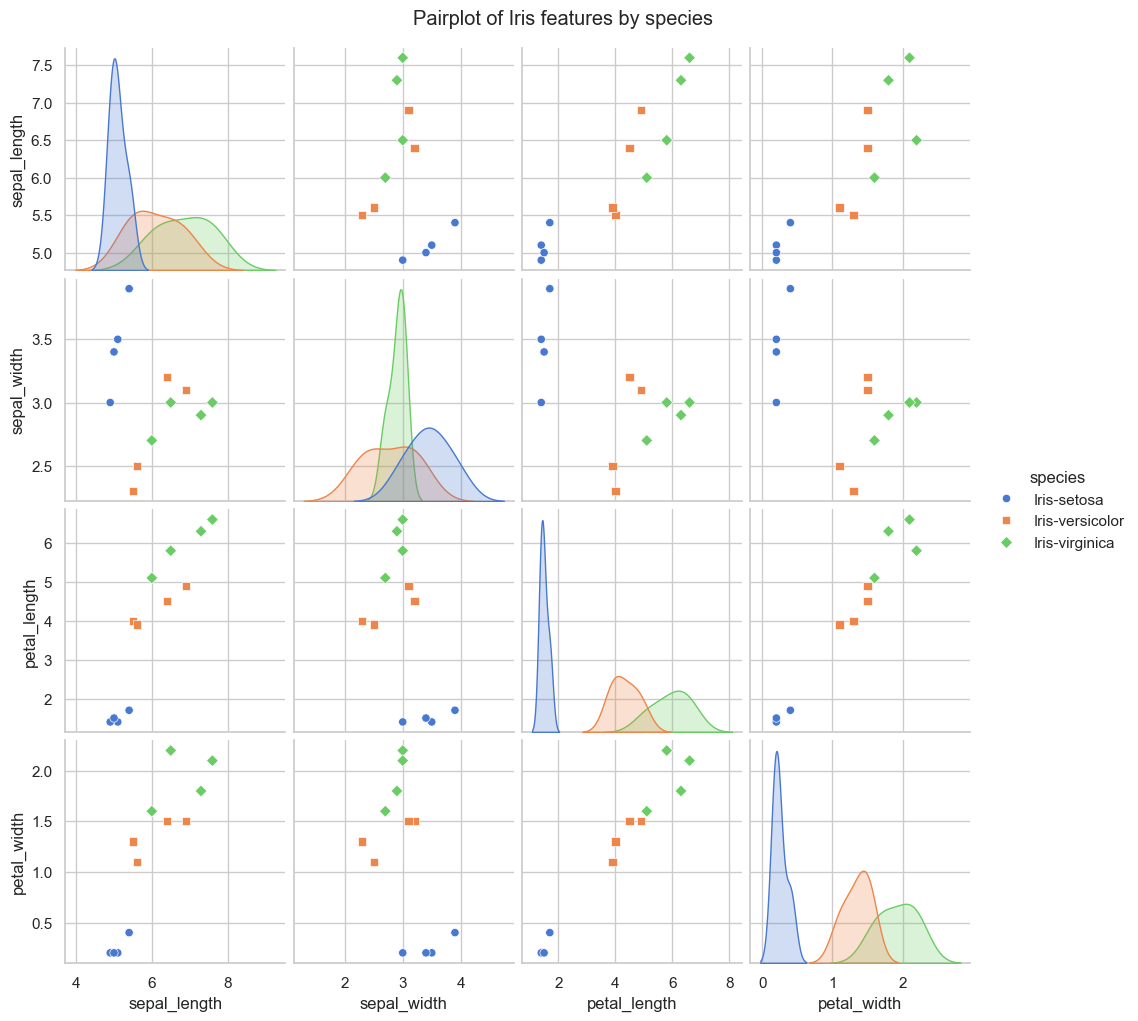

In [ ]:
# Visualizations
plt.figure(figsize=(8, 6))
sns.pairplot(iris_no_null, hue='species', markers=['o', 's', 'D']) #Shows relation between features 
plt.suptitle('Pairplot of Iris features by species', y=1.02)
plt.show()

<Figure size 1000x600 with 0 Axes>

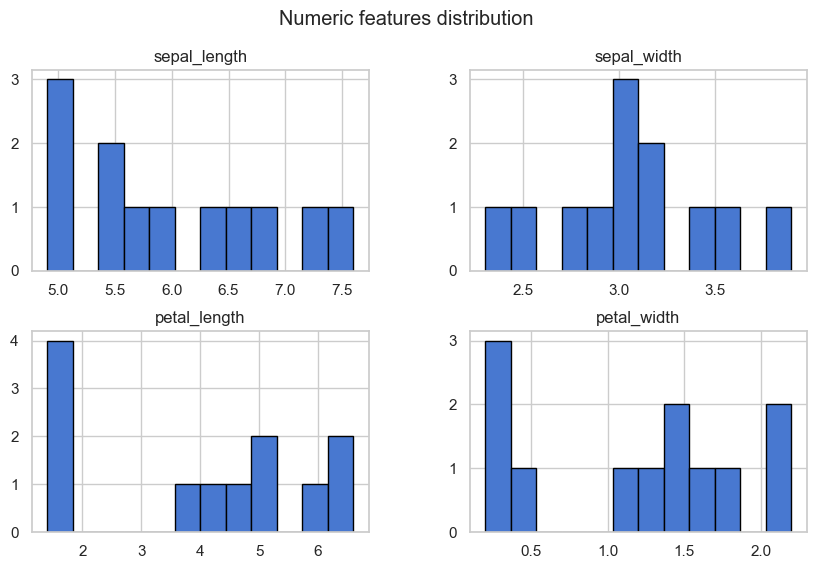

In [ ]:
# Histograms for numeric features HOW DISTRIBUTED
plt.figure(figsize=(10, 6))

numeric_cols = iris_no_null.select_dtypes(include=['float64', 'int64']).columns

iris_no_null[numeric_cols].hist(bins=12, layout=(2,2), figsize=(10,6), edgecolor='black')

plt.suptitle('Numeric features distribution')
plt.show()

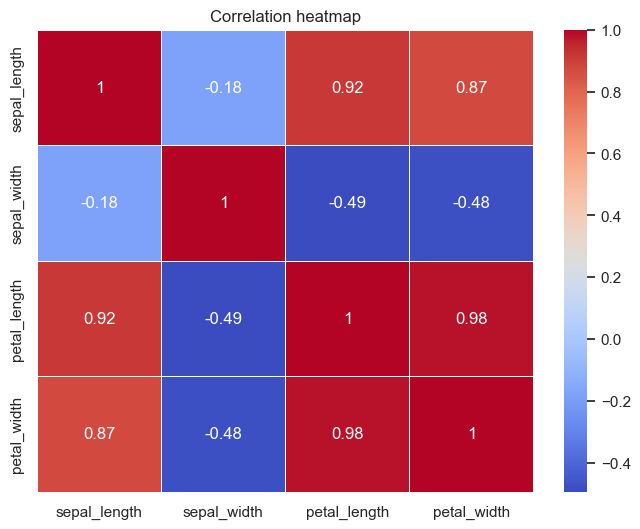

In [23]:
# Correlation between features
plt.figure(figsize=(8, 6))
sns.heatmap(iris_no_null[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')
plt.show()

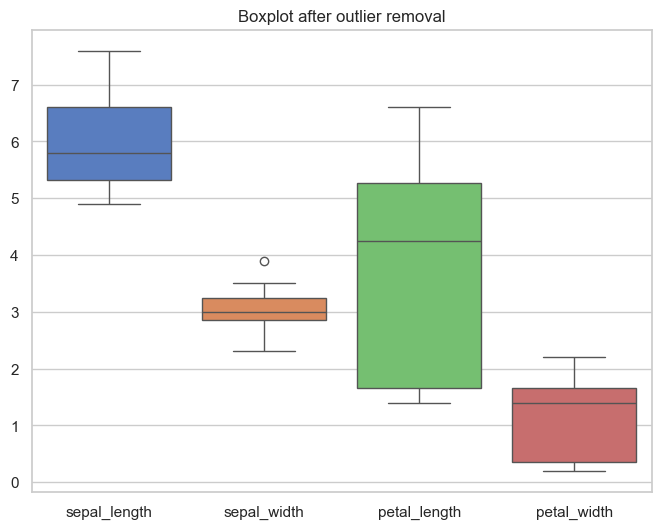

In [24]:
# Visualizations: boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data=iris_no_null[numeric_cols])
plt.title('Boxplot after outlier removal')
plt.show()

Shape after outlier cleanup: (11, 5)


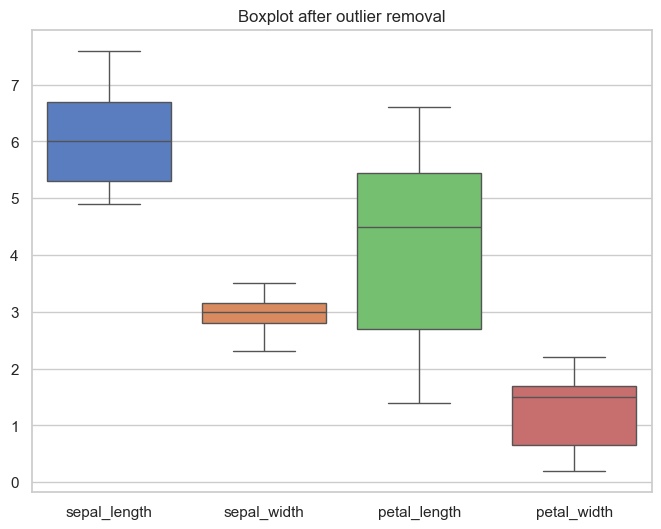

In [73]:
# Outlier detection and removal using IQR
iris_clean = iris_no_null.copy()

Q1 = iris_no_null[numeric_cols].quantile(0.25)
Q3 = iris_no_null[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Removes extreme values
iris_clean = iris_no_null[
    ~((iris_no_null[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (iris_no_null[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print('Shape after outlier cleanup:', iris_clean.shape)

plt.figure(figsize=(8,6))
sns.boxplot(data=iris_clean[numeric_cols])
plt.title('Boxplot after outlier removal')
plt.show()

In [29]:
# Converting Categorical Column 'Species' into numeric column.
le = LabelEncoder()
iris_clean['species_num'] = le.fit_transform(iris_clean['species'])
print('species mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

species mapping:  {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [61]:
iris_clean.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,5.0,3.4,1.5,0.2,Iris-setosa
3,6.4,3.2,4.5,1.5,Iris-versicolor
4,6.9,3.1,4.9,1.5,Iris-versicolor


In [67]:
# Separating Features and Labels for model.
X = iris_clean[numeric_cols].copy()
y = iris_clean['species']

In [45]:
# Splitting the data inot Train-Test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8, 4)
Test shape: (3, 4)


In [46]:
# Naive Bayes classification model Training model on data
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [75]:
# Predicting the results on test data.
y_pred = model.predict(X_test)
print('Predicted:', y_pred[:10])
print('Actual   :', y_test.values[:10])

Predicted: [2 1 0]
Actual   : [2 1 0]


Confusion Matrix:
 [[1 0 0]
 [0 1 0]
 [0 0 1]]


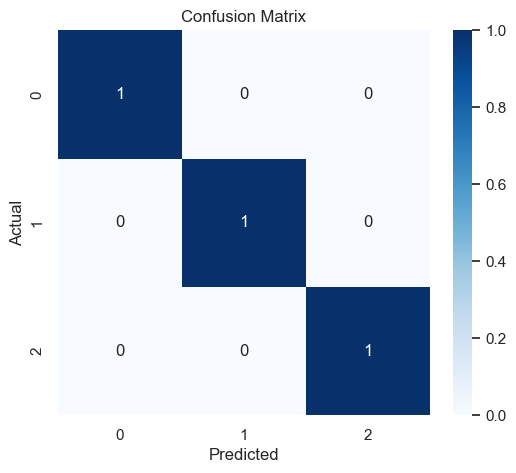

In [76]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
# 
mcm = multilabel_confusion_matrix(y_test, y_pred)

for i, class_name in enumerate(le.classes_):
    tn, fp, fn, tp = mcm[i].ravel()
    print(f"\nClass: {class_name}")
    print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")


Class: Iris-setosa
TP=1, FP=0, TN=2, FN=0

Class: Iris-versicolor
TP=1, FP=0, TN=2, FN=0

Class: Iris-virginica
TP=1, FP=0, TN=2, FN=0


In [ ]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [51]:
# Detailed classification report
from sklearn.metrics import classification_report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         1
Iris-versicolor       1.00      1.00      1.00         1
 Iris-virginica       1.00      1.00      1.00         1

       accuracy                           1.00         3
      macro avg       1.00      1.00      1.00         3
   weighted avg       1.00      1.00      1.00         3

